# Numpy

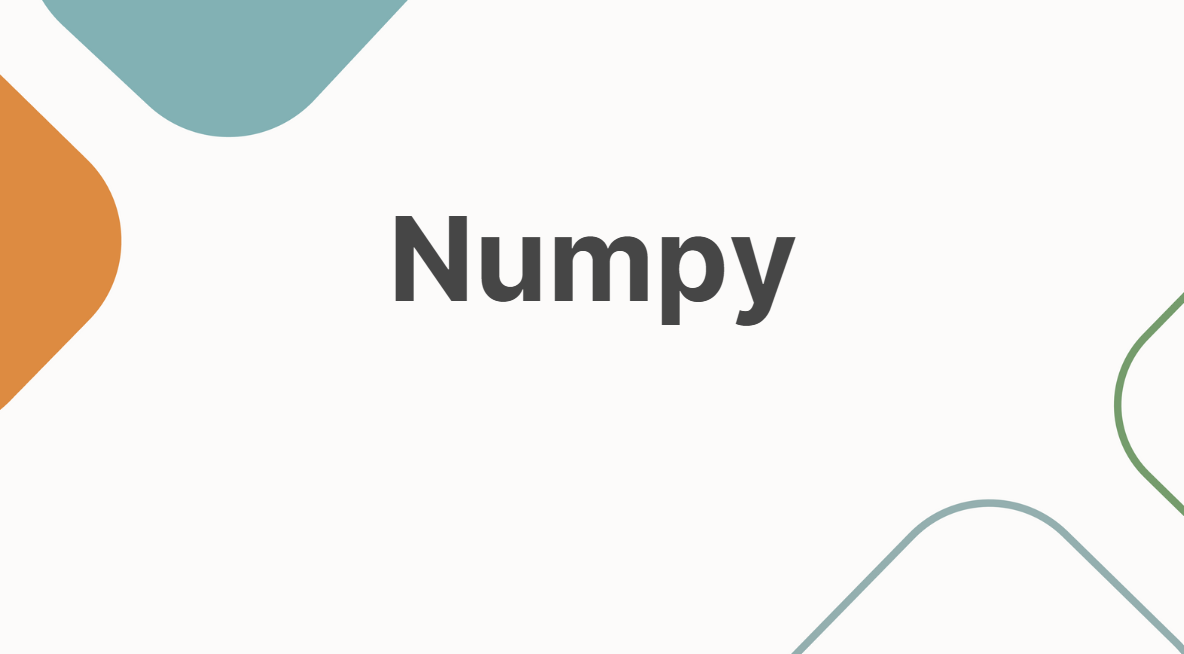

Array:

* Almacena datos todos del mismo tipo (por ejemplo, solo enteros o solo flotantes).

* Está optimizado para operaciones rápidas y vectorizadas.

* Consume menos memoria que una lista para la misma cantidad de datos.

* Permite operaciones matemáticas directas sin usar bucles explícitos.

In [ ]:
array = np.array([10, 20, 30, 40, 50])

In [ ]:
# Lista com 1 milhão de elementos
lista = list(range(1_000_000))

# Multiplicando cada elemento por 2 com um loop
resultado = []
for numero in lista: resultado.append(numero * 2)

In [ ]:
# Array de 1 milhão de elementos
array = np.arange(1_000_000)

# Multiplicando todos os elementos por 2 de forma vetorizada
resultado = array * 2

Por ejemplo, si tienes el vector 𝑣 ⃗ = [ 1 , 2 , 3, ... ] y lo multiplicas por 2, el resultado es [ 2 , 4 , 6, ... ].

# 🧮 Funciones comunes de NumPy para análisis y transformación numérica:

* np.array(): Crea un arreglo de NumPy a partir de listas o tuplas.
* np.arange(): Genera una secuencia de números con un paso definido.
* np.linspace(): Crea un array con valores equidistantes entre dos límites.
* np.zeros((filas, columnas)): Genera un array lleno de ceros.
* np.ones((filas, columnas)): Genera un array lleno de unos.
* np.eye(n): Crea una matriz identidad de tamaño n x n.
* np.reshape(array, nueva_forma): Cambia la forma del array sin alterar sus datos.
* np.sum(array, axis=...): Calcula la suma de los elementos.
* np.mean(array): Calcula el promedio de los valores.
* np.std(array): Calcula la desviación estándar.
* np.max(array) / np.min(array): Encuentra el valor máximo o mínimo.
* np.dot(a, b) o a @ b: Realiza multiplicación de matrices.
* np.concatenate([a, b], axis=...): Une arrays en una dimensión específica.
* np.stack([a, b]): Apila arrays creando una nueva dimensión.
* array[a > valor]: Filtra elementos usando condiciones booleanas.
* array.astype(tipo): Convierte el tipo de datos del array (por ejemplo, de float a int).





# 🚗 El Dilema de la Agencia de Autos del Sur

Hace algunos años, la **Agencia de Autos del Sur**, una concesionaria tradicional en América Latina, empezó a digitalizar sus procesos. Durante mucho tiempo, sus registros de ventas se guardaban en hojas de cálculo antiguas, formularios incompletos e incluso en cuadernos escritos a mano.

Con la llegada de la competencia digital y el aumento del comercio electrónico, el gerente decidió actuar. Exportó todos los datos históricos a un archivo `.csv`... pero el resultado no fue tan perfecto.

📉 El archivo está lleno de problemas:
- Datos faltantes en varias columnas importantes,
- Registros incompletos,
- Inconsistencias que dificultan cualquier análisis.

🎯 **Tu misión hoy** es asumir el rol de analista de datos y ayudar a esta agencia a transformar este archivo crudo en un conjunto limpio, confiable y listo para análisis.

Utilizaremos **Pandas** para explorar y leer los datos, y aplicaremos **NumPy** para hacer transformaciones avanzadas, como:
- Identificar valores perdidos,
- Reemplazar datos ausentes de forma inteligente,
- Limpiar registros inútiles y reconstruir el conjunto.

Este ejercicio forma parte del proceso **ETL** — especialmente la etapa de **Transformación** — y te ayudará a comprender cómo usar `NumPy` y `Pandas` de manera conjunta para resolver problemas del mundo real.

¡Manos a la obra! 🛠️

🔹 0. Importación y lectura de datos

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/car-sales-extended-missing-data.csv")
df


,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0
...,...,...,...,...,...
995,Toyota,Black,35820.0,4.0,32042.0
996,NaN,White,155144.0,3.0,5716.0
997,Nissan,Blue,66604.0,4.0,31570.0
998,Honda,White,215883.0,4.0,4001.0


🔹 1. Exploración general del conjunto de datos

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Make           951 non-null    object 
 1   Colour         950 non-null    object 
 2   Odometer (KM)  950 non-null    float64
 3   Doors          950 non-null    float64
 4   Price          950 non-null    float64
dtypes: float64(3), object(2)
memory usage: 39.2+ KB




 📘 Diccionario de Datos

| Columna         | Tipo de Dato | Traducción            | Descripción                                               |
| --------------- | ------------ | --------------------- | --------------------------------------------------------- |
| `Make`          | `object`     | **Marca**             | Marca del automóvil (por ejemplo, Toyota, Ford, etc.).    |
| `Colour`        | `object`     | **Color**             | Color del automóvil. Puede haber valores perdidos (NaN).  |
| `Odometer (KM)` | `float64`    | **Odómetro (KM)**     | Distancia total recorrida por el vehículo, en kilómetros. |
| `Doors`         | `float64`    | **Número de puertas** | Cantidad de puertas del vehículo.                         |
| `Price`         | `float64`    | **Precio**            | Precio de venta del vehículo en moneda local.             |




In [ ]:
#contando valores nulos
df.isna().sum()

,0
Make,49
Colour,50
Odometer (KM),50
Doors,50
Price,50


 🔹2. Extracción de columnas como arrays NumPy

In [ ]:
odometro_np = df["Odometer (KM)"].to_numpy()

precio_np = df["Price"].to_numpy()

Al convertir columnas a arrays NumPy, ganamos flexibilidad para aplicar funciones matemáticas de forma eficiente.

🔹 3. Detección y reemplazo de valores faltantes con NumPy

In [ ]:
np.isnan(odometro_np)

array([False, False, False, False, False, False, False,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,



📌 Imputación de valores faltantes (NaN)

La **imputación** es el proceso de **rellenar datos faltantes** en un conjunto de datos. Esto es importante porque muchos algoritmos no pueden procesar valores nulos, y eliminar datos puede hacernos perder información valiosa.

 ✅ Métodos comunes:

* **Media / Mediana / Moda**: Para datos numéricos o categóricos simples.
* **Condicional**: Usar promedios según grupos (ej. precio medio por marca).
* **Modelos predictivos**: Usar KNN o regresión para estimar valores.
* **Eliminación**: Solo si hay muchos datos faltantes.

Imputar permite mantener la calidad del análisis sin descartar registros útiles.




In [ ]:
media_odometro = np.nanmean(odometro_np)
media_odometro

np.float64(131253.23789473684)

In [ ]:
odometro_limpio = np.where(np.isnan(odometro_np), media_odometro, odometro_np)
odometro_limpio

array([ 35431.        , 192714.        ,  84714.        , 154365.        ,
       181577.        ,  42652.        , 163453.        , 131253.23789474,
       130538.        ,  51029.        , 167421.        ,  17119.        ,
       102303.        , 134181.        , 199833.        , 205592.        ,
        96742.        , 194189.        ,  67991.        , 215820.        ,
       124844.        ,  30615.        , 148744.        , 130075.        ,
       172718.        , 125819.        , 180390.        ,  82783.        ,
        56687.        , 112004.        ,  34024.        , 108569.        ,
       203795.        , 153554.        ,  71949.        , 191622.        ,
        38186.        , 131253.23789474, 146430.        , 109868.        ,
       177894.        , 189209.        , 200490.        , 141617.        ,
       213893.        , 231057.        , 100938.        , 243969.        ,
       107096.        ,  86333.        , 184878.        , 161068.        ,
        77646.        , 2

Aquí aplicamos una imputación simple usando NumPy: sustituimos los valores ausentes por la media. Es rápido, eficiente y sin bucles.

🔹 4. Manipulación de columnas de texto con NumPy

In [ ]:
color_np = df["Colour"].to_numpy(dtype="object")
color_np[np.where(pd.isna(color_np))] = "Desconocido"
color_np

array(['White', 'Blue', 'White', 'White', 'Blue', 'Red', 'Blue', 'White',
       'White', 'Blue', 'White', 'Green', 'White', 'White', 'Blue',
       'Blue', 'Red', 'White', 'White', 'Blue', 'Desconocido',
       'Desconocido', 'White', 'Green', 'Blue', 'Blue', 'White', 'Green',
       'White', 'White', 'Blue', 'White', 'White', 'Green', 'Blue',
       'Blue', 'Blue', 'White', 'Blue', 'Green', 'White', 'Blue', 'Black',
       'Blue', 'Blue', 'Blue', 'White', 'Blue', 'White', 'Black', 'Red',
       'White', 'Blue', 'Blue', 'White', 'White', 'White', 'Red',
       'Desconocido', 'Blue', 'Red', 'Black', 'Green', 'Green', 'White',
       'White', 'Blue', 'Black', 'Blue', 'White', 'White', 'Desconocido',
       'White', 'Red', 'Blue', 'Blue', 'Blue', 'White', 'Blue', 'Blue',
       'Black', 'Blue', 'Blue', 'Blue', 'Green', 'Blue', 'Blue',
       'Desconocido', 'Red', 'Blue', 'White', 'White', 'White', 'White',
       'Green', 'Blue', 'Blue', 'Black', 'Red', 'Desconocido', 'Blue',
       'Whi

Aunque estemos tratando con texto, también podemos usar NumPy. Aquí reemplazamos valores nulos por "Desconocido".

🔹 5. Filtrado de filas con muchos datos faltantes

In [ ]:
matriz_nan = pd.isna(df).to_numpy()
matriz_nan


array([[False, False, False, False, False],
       [False, False, False, False, False],
       [False, False, False, False, False],
       ...,
       [False, False, False, False, False],
       [False, False, False, False, False],
       [False, False, False, False, False]])

In [ ]:
nan_por_fila = matriz_nan.sum(axis=1)
nan_por_fila

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 2, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,

In [ ]:
filas_validas = nan_por_fila < (df.shape[1] / 2)
filas_validas

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

Cuando una fila está muy incompleta, puede ser mejor descartarla. Aquí usamos una regla: mantener solo filas que tengan al menos la mitad de los datos completos.

🔹 6. Reconstrucción del DataFrame limpio

In [ ]:
df_limpio = df[filas_validas].copy()
df_limpio['Odometer (KM)'] = odometro_limpio[filas_validas]
df_limpio['Price'] = np.where(np.isnan(precio_np), 0, precio_np)[filas_validas]
df_limpio['Colour'] = color_np[filas_validas]
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Make           951 non-null    object 
 1   Colour         999 non-null    object 
 2   Odometer (KM)  999 non-null    float64
 3   Doors          950 non-null    float64
 4   Price          999 non-null    float64
dtypes: float64(3), object(2)
memory usage: 46.8+ KB


In [ ]:
df.isna().sum()


,0
Make,49
Colour,0
Odometer (KM),50
Doors,50
Price,50


In [ ]:
df_limpio.isna().sum()

,0
Make,48
Colour,0
Odometer (KM),0
Doors,49
Price,0


🤔 ¿Por qué estamos usando NumPy y no Pandas?
Aunque Pandas es una herramienta más práctica para tratar datos, en esta clase elegimos usar NumPy para fortalecer la comprensión de los fundamentos de la manipulación de datos numéricos.

✅ ¿Por qué aprender con NumPy?

* NumPy es la base de Pandas: todo lo que hace Pandas por detrás, lo hace con arrays de NumPy.
* Más control sobre los datos: al usar NumPy, trabajamos directamente con cadenas, valores ausentes, conversión de tipos y normalización de datos.
* Es esencial para el ML y la ciencia de datos: bibliotecas como Scikit-learn y TensorFlow usan NumPy directamente.
* Entrenamiento del razonamiento analítico: al tratar los datos paso a paso con NumPy, entendemos cómo se procesan realmente los datos.

👨‍🏫 Nuestro objetivo aquí:
"Entender lo que ocurre tras bambalinas para luego usar herramientas más poderosas con conciencia."

Más adelante, verás cómo resolver el mismo problema con Pandas en pocas líneas... pero ahora sabrás lo que ocurre detrás de esas líneas 😉
